# Install the required packages

In [ ]:
!pip install transformers sentencepiece

# Load the Donut model

In [1]:
import torch

device = "cpu"
# Use mps if available
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"

In [2]:
from transformers import VisionEncoderDecoderModel, DonutProcessor

checkpoint_name = "naver-clova-ix/donut-base-finetuned-docvqa"

model = VisionEncoderDecoderModel.from_pretrained(checkpoint_name).to(device)
processor = DonutProcessor.from_pretrained(checkpoint_name)

VisionEncoderDecoderModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
/Users/nim/Repositories/ocr-skooldio/.venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenizatio

# Load document

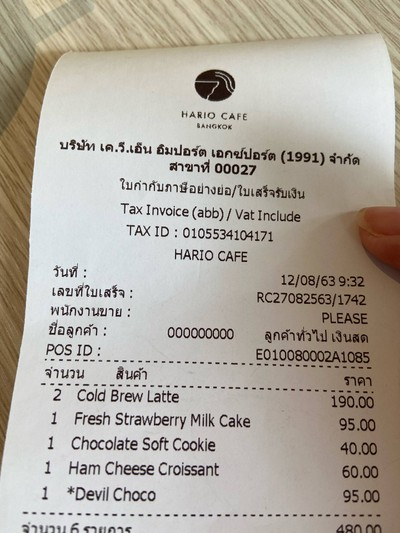

In [3]:
from PIL import Image

path = "../assets/donut_receipt_example.jpg"
image = Image.open(path).convert("RGB")

display(image)

# Run inference

In [5]:
import re

questions = [
    "How much is the Chocolate Soft Cookie?",
    "What is the TAX ID?",
    "What is the total quantity of Cold Brew Latte?",
]

for question in questions:
    task_prompt = "<s_docvqa><s_question>{user_input}</s_question><s_answer>"
    prompt = task_prompt.format(user_input=question)
    # Tokenize the prompt into input_ids
    decoder_input_ids = processor.tokenizer(
        prompt, add_special_tokens=False, return_tensors="pt"
    ).input_ids
    # Convert the image into pixel_values
    pixel_values = processor(image, return_tensors="pt").pixel_values

    outputs = model.generate(
        pixel_values.to(device),
        decoder_input_ids=decoder_input_ids.to(device),
        max_length=model.decoder.config.max_position_embeddings,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        bad_words_ids=[[processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )

    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(
        processor.tokenizer.pad_token, ""
    )
    sequence = re.sub(
        r"<.*?>", "", sequence, count=1
    ).strip()  # remove first task start token
    print(processor.token2json(sequence))

{'question': 'How much is the Chocolate Soft Cookie?', 'answer': '40.00'}
{'question': 'What is the TAX ID?', 'answer': '0105534104171'}
{'question': 'What is the total quantity of Cold Brew Latte?', 'answer': '2'}
